## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

## 2. Load and Preprocess the Dataset

In [5]:
# Load dataset
iris = load_iris()

# Convert to dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add species column
df['species'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### The Iris dataset contains 150 samples of flowers with four features:

#### Sepal Length

#### Sepal Width

#### Petal Length

#### Petal Width

### Drop the Species Column

#### Since clustering is unsupervised learning, we remove the species column.

In [6]:
X = df.drop('species', axis=1)
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Feature Scaling

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. KMeans Clustering

#### KMeans clustering is an unsupervised machine learning algorithm used to group similar data points into clusters.

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

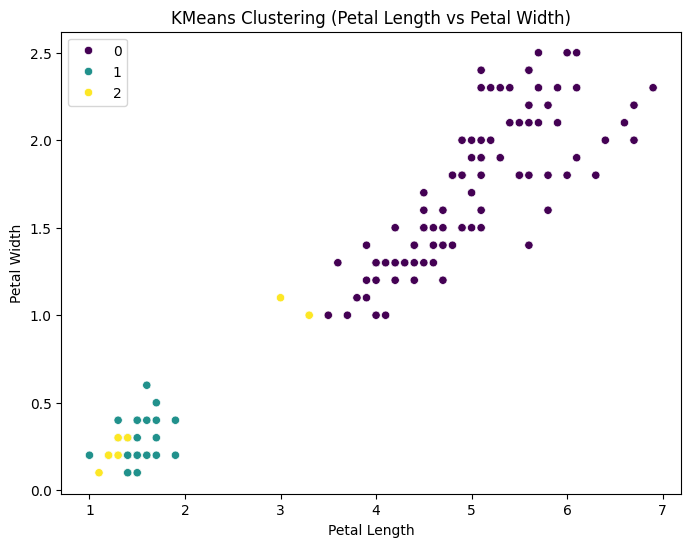

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X.iloc[:,2], y=X.iloc[:,3], hue=kmeans_labels, palette='viridis')

plt.title("KMeans Clustering (Petal Length vs Petal Width)")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.show()

##### Why KMeans is Suitable for Iris Dataset

##### KMeans works well when:

##### 1.Dataset size is small

##### 2.Clusters are clearly separable

##### 3.Numeric features are present

##### The Iris dataset satisfies these conditions since it has numeric measurements of flower parts and naturally forms 3 clusters.

## 4. Hierarchical Clustering

##### Hierarchical clustering builds clusters step by step using a tree-like structure called a dendrogram.

##### Two approaches:

##### 1.Agglomerative (Bottom-up)

##### 2.Divisive (Top-down)

##### In this project we use Agglomerative Clustering.

In [12]:
hc = AgglomerativeClustering(n_clusters=3)

hc_labels = hc.fit_predict(X_scaled)

df['HC_Cluster'] = hc_labels

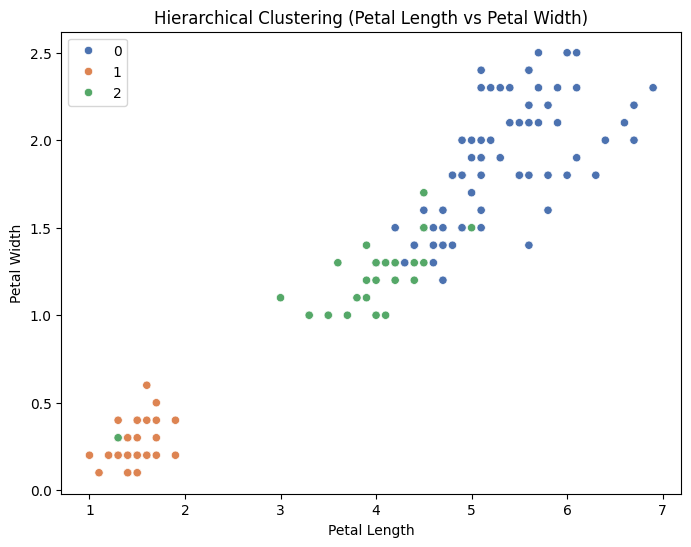

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=X.iloc[:,2], y=X.iloc[:,3], hue=hc_labels, palette='deep')

plt.title("Hierarchical Clustering (Petal Length vs Petal Width)")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.show()

##### Why Hierarchical Clustering is Suitable for Iris Dataset

##### Hierarchical clustering works well when:

##### 1.Dataset is small

##### 2.Cluster hierarchy is useful

##### 3.Number of clusters is not known beforehand

##### The Iris dataset is small (150 samples), making it ideal for hierarchical clustering.

## 5. Conclusion

### Both clustering algorithms successfully grouped the Iris dataset into clusters.

### Observations:

### 1.KMeans quickly forms clusters based on centroids.

### 2.Hierarchical clustering forms clusters based on distance hierarchy.

### 3.The Iris dataset naturally forms three clusters corresponding to the three species.